# quiz 1 基礎

In [1]:
import torch
import torch.nn as nn
import importlib
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from other_code import quiz1

importlib.reload(quiz1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
DATA_ROOT = Path("./dataset/Intel Image Classification")
CLASS_NAMES = [
    "buildings", "forest", "glacier",
    "mountain", "sea", "street"
]
VALID_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

records = []

for split in ["seg_train", "seg_test", "seg_pred"]:
    split_dir = DATA_ROOT / split

    if not split_dir.is_dir():
        raise FileNotFoundError(f"找不到資料夾：{split_dir.resolve()}")

    if split != "seg_pred":
        for name in CLASS_NAMES:
            if not (split_dir / name).is_dir():
                raise FileNotFoundError(f"找不到類別資料夾：{split_dir / name}")

    paths = sorted(
        p for p in split_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    )

    for path in tqdm(paths, desc=f"檢查 {split}"):
        if split != "seg_pred":
            label = path.relative_to(split_dir).parts[0]
        else:
            label = None

        row = {
            "split": split,
            "path": str(path),
            "label": label,
            "width": None,
            "height": None,
            "mode": None,
            "error": None,
        }

        try:
            with Image.open(path) as img:
                img.load()
                row.update(
                    width=img.width,
                    height=img.height,
                    mode=img.mode,
                )
        except Exception as exc:
            row["error"] = str(exc)

        records.append(row)

image_df = pd.DataFrame(records)

if image_df.empty:
    raise ValueError("沒有找到圖片，請確認DATA_ROOT和副檔名。")

print("圖片總數：", len(image_df))
print("檢查表row/col：", image_df.shape)

print("\n各資料集圖片數：")
display(image_df.groupby("split").size().rename("count").to_frame())

print("\n各類圖片數：")
display(pd.crosstab(image_df["label"], image_df["split"]))

valid_df = image_df[image_df["error"].isna()].copy()

print("\n最常見的圖片尺寸(寬、高)：")
display(valid_df.groupby(["width", "height"]).size().sort_values(ascending=False).head(10).rename("count").to_frame())

print("\n圖片色彩模式：")
display(valid_df["mode"].value_counts().rename("count").to_frame())

bad_df = image_df[image_df["error"].notna()]
print("\n無法讀取的圖片數：", len(bad_df))
display(bad_df[["path", "error"]].head(10))

unexpected = (
    set(image_df["label"].dropna()) - set(CLASS_NAMES)
)
print("\n非預期的類別：", unexpected)

檢查 seg_train:   0%|          | 0/14034 [00:00<?, ?it/s]

檢查 seg_test:   0%|          | 0/3000 [00:00<?, ?it/s]

檢查 seg_pred:   0%|          | 0/7301 [00:00<?, ?it/s]

圖片總數： 24335
檢查表row/col： (24335, 7)

各資料集圖片數：


,count
split,
seg_pred,7301
seg_test,3000
seg_train,14034


...


圖片色彩模式：


,count
mode,
RGB,24335



無法讀取的圖片數： 0


,path,error



非預期的類別： set()


In [3]:
train_pool = valid_df[valid_df["split"] == "seg_train"].copy()
test_df = valid_df[valid_df["split"] == "seg_test"].copy()

train_df, val_df = train_test_split(train_pool, test_size=0.2, random_state=42, stratify=train_pool["label"])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 11227
Val: 2807
Test: 3000


In [4]:
image_size = 224
Batch_size = 64
train_transform, eval_transform = quiz1.build_transforms(image_size)

train_set = quiz1.IntelDataset(train_df, train_transform)
val_set = quiz1.IntelDataset(val_df, eval_transform)
test_set = quiz1.IntelDataset(test_df, eval_transform)

train_loader = DataLoader(train_set, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=Batch_size, shuffle=False, num_workers=0)

In [ ]:
Learning_rate = 1e-4
Weight_decay = 1e-4
Epochs = 20

model = quiz1.build_resnet18(num_classes=6, pretrained=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

output_dir = Path("./result/resnet18")
output_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_dir / "best.pt"
history_path = output_dir / "history.csv"

history = []
best_val_acc = -1.0

for epoch in range(Epochs):
    train_loss, train_acc = quiz1.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = quiz1.evaluate(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"Epoch {epoch + 1}/{Epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), checkpoint_path)
        print("\n已儲存最佳模型")

print(f"\nBest val acc: {best_val_acc:.4f}")

Train:   0%|          | 0/176 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1/20 | Train loss: 0.2918 | Train acc: 0.9011 | Val loss: 0.2243 | Val acc: 0.9198

已儲存最佳模型


Train:   0%|          | 0/176 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/44 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 19/20 | Train loss: 0.0089 | Train acc: 0.9971 | Val loss: 0.3417 | Val acc: 0.9280


Train:   0%|          | 0/176 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 20/20 | Train loss: 0.0104 | Train acc: 0.9963 | Val loss: 0.3222 | Val acc: 0.9352

Best val acc: 0.9391


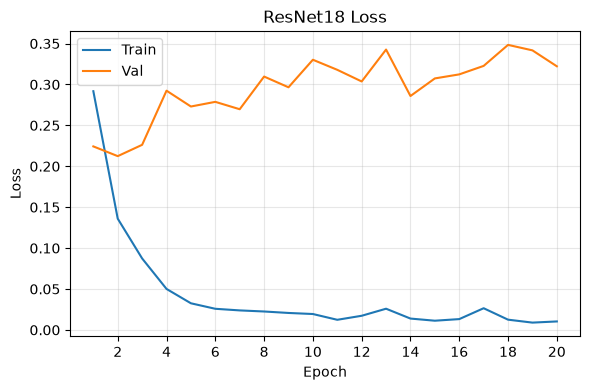

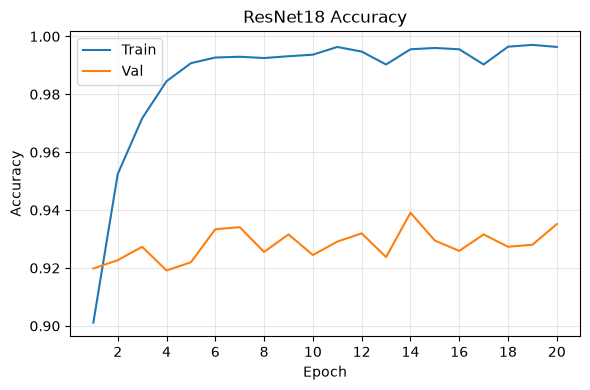

In [13]:
history_df = pd.read_csv("./result/resnet18/history.csv")

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val")
plt.title("ResNet18 Loss")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/resnet18/loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val")
plt.title("ResNet18 Accuracy")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/resnet18/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()